# Modul 4 - Preview

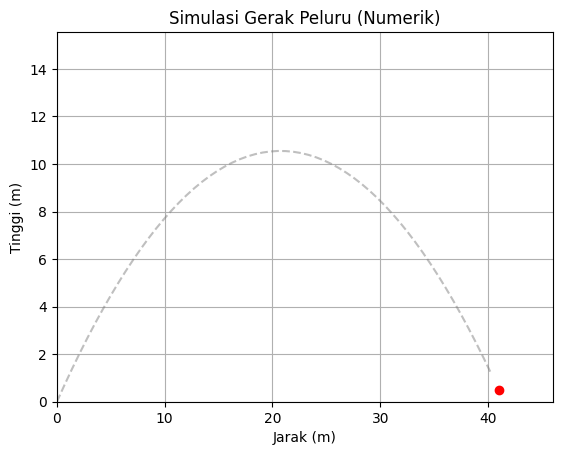

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# 1. Parameter Fisis
g = 9.81
v0 = 20.0       # Kecepatan awal (m/s)
theta = 45.0    # Sudut elevasi (derajat)
dt = 0.05

# Komponen kecepatan awal
vx = v0 * np.cos(np.radians(theta))
vy = v0 * np.sin(np.radians(theta))

# 2. Inisialisasi State [x, y, vx, vy]
state = np.array([0.0, 0.0, vx, vy])
path_x, path_y = [], []

# 3. Loop Numerik (Metode Euler)
while state[1] >= 0:  # Selama objek di atas tanah
    path_x.append(state[0])
    path_y.append(state[1])
    
    # Update Posisi
    state[0] += state[2] * dt #untuk menentukan x
    state[1] += state[3] * dt #untuk menentukan y
    
    # Update Kecepatan
    state[3] -= g * dt #untuk menentukan vy (dv/dt = -g)
    #untuk menentukan vx, hitung secara numerik untuk state[2]

# 4. Animasi
fig, ax = plt.subplots()
ax.set_xlim(0, max(path_x)+5)
ax.set_ylim(0, max(path_y)+5)
line, = ax.plot([], [], 'o-', color='red', markevery=[-1])
trail, = ax.plot([], [], '--', color='gray', alpha=0.5)

def update(frame):
    trail.set_data(path_x[:frame], path_y[:frame])
    line.set_data([path_x[frame]], [path_y[frame]])
    return line, trail

ani = FuncAnimation(fig, update, frames=len(path_x), interval=20, blit=True)
plt.title("Simulasi Gerak Peluru (Numerik)")
plt.xlabel("Jarak (m)"); plt.ylabel("Tinggi (m)")
plt.grid(True)
ani.save("peluru.gif", writer="pillow") #Opsional untuk menyimpan GIF
plt.show()

Kode di atas merupakan kode awal yang akan diuji di tugas praktikum. Untuk penjelasan mengenai bagian mana saja yang harus diubah, bisa cek bagian berikutnya.

## 1. **Rekonstruksi Hambatan Udara:** 

Masukkan gaya hambat udara (air drag) $F_d = -kv^2$ ke dalam model gerak peluru. Tuliskan kembali bahasa matematikanya untuk komponen sumbu x dan y, lalu amati bagaimana bentuk lintasan berubah dibandingkan dengan tanpa hambatan udara (efek *ballistic trajectory*).

Diketahui gaya hambat udara non-linear $F_d = -kv^2$ (tidak sama dengan model yang ada di teori dasar), sehingga $$ma = mg - kv^2$$ $$m \frac{dv}{dt}= mg - kv^2$$ sehingga: $$\frac{dv}{dt} = \frac{mg}{m} - \frac{kv^2}{m}$$ $$\frac{dv}{dt} = g - \frac{k}{m}v^2$$ Gunakan persamaan berikut sebagai model matematis yang akan digunakan untuk tugas nomor 1. Jangan lupa tentukan nilai k nya ya! 

Note: untuk nilai k, bisa gunakan nilai yang umum dipakai untuk simulasi sederhana yaitu $k = 0.001$. Namun, akan lebih mantep kalau kita gunakan persamaan $k = \frac{1}{2}C_d\rho A$ untuk menentukan nilai k nya dengan $C_d =$ koefisien drag, $\rho =$ densitas udara, dan $A =$ luas penampang (coba-coba aja gess).

Untuk simulasi, kita gunakan sistem PDB berikut:
$$\frac{dx}{dt} = v_x, \quad \frac{dv_x}{dt} = -\frac{k}{m}vv_x$$
$$\frac{dy}{dt} = v_y, \quad \frac{dv_y}{dt} = -g - \frac{k}{m}vv_y$$
dengan $v = \sqrt{v_x^2 + v_y^2}$

Algoritma:
1. Tentukan parameter fisis. jangan lupa untuk menghitung v
<br> 
ubah
```
vx = v0 * np.cos(np.radians(theta)) 
vy = v0 * np.sin(np.radians(theta))
```
menjadi
```
vx = v0 * np.cos(np.radians(theta))
vy = v0 * np.sin(np.radians(theta))
v = np.sqrt(vx**2 + vy**2)
```
2. Inisialisasi state
3. Hitung secara numerik nilai kecepatan dengan menambahkan:
<br>
```state[2] =``` $-\frac{k}{m}vv_x \cdot dt$ untuk vx dan ```state[3] =```$-g - \frac{k}{m}vv_y \cdot dt$ untuk vy
4. Tampilkan hasil simulasi

Output yang diharapkan:
Animasi hasil simulasi, untuk contoh bisa lihat file peluru_drag.gif

## 2. **Analisis Jarak Maksimum:** 

Gunakan simulasi untuk mencari sudut elevasi yang menghasilkan jarak terjauh (range) jika hambatan udara diperhitungkan secara signifikan. Apakah sudut optimalnya tetap berada di $45^\circ$? Jelaskan alasan fisisnya.

Algoritma:
1. Gunakan kode dari tugas nomor 1.
2. Ubah ```theta = 45.0``` menjadi ```theta = np.array([15, 30, 45, 60, 75])```. Variasikan list theta-nya.
3. Buat ```all_paths_x = []``` dan ``` all_paths_y = []``` untuk menyimpan semua lintasan. Untuk bagian loop, perlu dilakukan looping dengan ```for theta in theta_list:```Simulasikan!

Output yang diharapkan:
Animasi hasil simulasi, untuk contoh bisa lihat file peluru_thetavar.gif

## 3. **Gerak Jatuh Bebas & Terminal Velocity:** 

Buatlah grafik kecepatan terhadap waktu ($v$ vs $t$) untuk kasus gerak jatuh bebas dengan hambatan udara. Tunjukkan secara numerik dan grafis bahwa benda akan mencapai **kecepatan terminal** ($v_{term}$) di mana percepatannya menjadi nol.

Untuk gerak jatuh bebas:
$$F = mg - bv$$
Sehingga kecepatan terminal ($v_{term}$) diperoleh ketika $$mg = bv$$ $$v_{term}= \frac{mg}{b}$$
Dari hasil perhitungan numerik, dapat dibuat grafik $v$ vs $t$ berdasarkan hasil perhitungan numeriknya.

Algoritma:
1. Tentukan parameter fisis, gunakan vx = 0 karena tidak memiliki kecepatan di komponen x
2. Inisialisasi state, serta array v dan t (krusial untuk membuat grafik)
<br>
Ubah
```
v0 = 20.0
theta = 45.0
vx = v0 * np.cos(np.radians(theta))
vy = v0 * np.sin(np.radians(theta))
state = np.array([0.0, 0.0, vx, vy])
```
menjadi
```
v0 = 0.0
theta = 45.0
vx = 0
vy = v0 * np.sin(np.radians(theta))
state = np.array([2.5, 50.0, vx, vy]) #contoh x = 2.5, y = 50
```


3. Hitung secara numerik untuk state[1] dan state[3]. Untuk state 3, ubah menjadi ```state[3] += (-g - (b/m) * v * state[3]) * dt``` mengikuti model matematis yang sebelumnya dibuat
4. Hitung vterm, lalu buat grafik v vs. t

Output yang diharapkan: Grafik v vs. t

## 4. **Visualisasi Komparatif:** 

Tampilkan dalam satu grafik lintasan peluru dengan tiga variasi koefisien hambat udara ($k$) yang berbeda.

Tinggal buat aja variasi k, lalu buat simulasi untuk masing-masing k. Simple, ges.

Algoritma
1. Gunakan kode pada tugas nomor 1
2. Buat variasi k dalam array ```k_list = [k1, k2, k3]```, bagian ini bebas divariasikan. Untuk bagian loop, pastikan loop berjalan untuk ```for k in k_list```
3. Tampilkan hasil simulasi untuk ketiga nilai k dalam satu grafik

note: untuk bagian ini, gunakan parameter lain (vx, vy, dll.) konstan. Hanya nilai k yang divariasikan

Output yang diharapkan:
Animasi hasil simulasi, untuk contoh bisa lihat file peluru_kvar.gif